1. IMPORT LIBRARIES

In [5]:
# AIR QUALITY ANALYSIS & PREDICTION
# IBM SkillsBuild Data Analytics Internship
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")


Libraries imported successfully.


2. LOAD DATASET

In [4]:
# 2. LOAD DATASET
# ============================================================


file_path = "AirQualityUCI.csv"

df = pd.read_csv(
    file_path,
    sep=";",
    decimal=","
)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


3. CLEAN EMPTY COLUMNS

In [6]:
# ============================================================
# 3. CLEAN EMPTY COLUMNS
# ============================================================


df = df.dropna(axis=1, how="all")

print("Shape after removing empty columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape after removing empty columns: (9471, 15)

Columns:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


4. COMBINE DATE AND TIME

In [7]:
# 4. COMBINE DATE AND TIME
# ============================================================

df["Date_Time"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True,
    errors="coerce"
)

df = df.drop(columns=["Date", "Time"])

df = df.set_index("Date_Time").sort_index()

print(df.head())


           CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
Date_Time                                                                    
NaT           2.6       1360.0     150.0      11.9         1046.0    166.0   
NaT           2.0       1292.0     112.0       9.4          955.0    103.0   
NaT           2.2       1402.0      88.0       9.0          939.0    131.0   
NaT           2.2       1376.0      80.0       9.2          948.0    172.0   
NaT           1.6       1272.0      51.0       6.5          836.0    131.0   

           PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH  \
Date_Time                                                                 
NaT              1056.0    113.0        1692.0       1268.0  13.6  48.9   
NaT              1174.0     92.0        1559.0        972.0  13.3  47.7   
NaT              1140.0    114.0        1555.0       1074.0  11.9  54.0   
NaT              1092.0    122.0        1584.0       1203.0  11.0  60.0   
NaT

5. REPLACE MISSING VALUE CODE

In [8]:
# 5. REPLACE MISSING VALUE CODE
# ============================================================

# In the original UCI dataset, -200 represents missing data.

df = df.replace(-200, np.nan)

print("Missing values:")
print(df.isnull().sum())


Missing values:
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64


6. CONVERT NUMERIC COLUMNS

In [9]:
# 6. CONVERT NUMERIC COLUMNS
# ============================================================

for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print(df.dtypes)


CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object


7. MISSING VALUE ANALYSIS

In [10]:
# 7. MISSING VALUE ANALYSIS
# ============================================================

missing = df.isnull().sum().sort_values(ascending=False)

missing_percentage = (
    missing / len(df) * 100
).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage
})

missing_table

,Missing Values,Missing Percentage
NMHC(GT),8557,90.35
CO(GT),1797,18.97
NO2(GT),1756,18.54
NOx(GT),1753,18.51
PT08.S1(CO),480,5.07
PT08.S2(NMHC),480,5.07
C6H6(GT),480,5.07
PT08.S3(NOx),480,5.07
PT08.S4(NO2),480,5.07
PT08.S5(O3),480,5.07


8. HANDLE MISSING VALUES

In [21]:
df = df[~df.index.isna()].copy()

# Make sure the index is sorted chronologically
df = df.sort_index()

# Time-based interpolation
df = df.interpolate(method="time")

# Fill any remaining missing values at the beginning/end
df = df.ffill().bfill()

print("Remaining missing values:", df.isnull().sum().sum())
print("Dataset shape:", df.shape)

Remaining missing values: 0
Dataset shape: (0, 18)


9. BASIC STATISTICS

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CO(GT),7674.0,2.152750,1.453252,0.1000,1.1000,1.8000,2.9000,11.900
PT08.S1(CO),8991.0,1099.833166,217.080037,647.0000,937.0000,1063.0000,1231.0000,2040.000
NMHC(GT),914.0,218.811816,204.459921,7.0000,67.0000,150.0000,297.0000,1189.000
C6H6(GT),8991.0,10.083105,7.449820,0.1000,4.4000,8.2000,14.0000,63.700
PT08.S2(NMHC),8991.0,939.153376,266.831429,383.0000,734.5000,909.0000,1116.0000,2214.000
NOx(GT),7718.0,246.896735,212.979168,2.0000,98.0000,180.0000,326.0000,1479.000
PT08.S3(NOx),8991.0,835.493605,256.817320,322.0000,658.0000,806.0000,969.5000,2683.000
NO2(GT),7715.0,113.091251,48.370108,2.0000,78.0000,109.0000,142.0000,340.000
PT08.S4(NO2),8991.0,1456.264598,346.206794,551.0000,1227.0000,1463.0000,1674.0000,2775.000
PT08.S5(O3),8991.0,1022.906128,398.484288,221.0000,731.5000,963.0000,1273.5000,2523.000


10. FEATURE ENGINEERING

In [13]:
df["Hour"] = df.index.hour
df["Day"] = df.index.day
df["Month"] = df.index.month
df["DayOfWeek"] = df.index.dayofweek

df["IsWeekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

print(df.head())

           CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
Date_Time                                                                    
NaT           2.6       1360.0     150.0      11.9         1046.0    166.0   
NaT           2.0       1292.0     112.0       9.4          955.0    103.0   
NaT           2.2       1402.0      88.0       9.0          939.0    131.0   
NaT           2.2       1376.0      80.0       9.2          948.0    172.0   
NaT           1.6       1272.0      51.0       6.5          836.0    131.0   

           PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH  \
Date_Time                                                                 
NaT              1056.0    113.0        1692.0       1268.0  13.6  48.9   
NaT              1174.0     92.0        1559.0        972.0  13.3  47.7   
NaT              1140.0    114.0        1555.0       1074.0  11.9  54.0   
NaT              1092.0    122.0        1584.0       1203.0  11.0  60.0   
NaT

11. CO CONCENTRATION OVER TIME

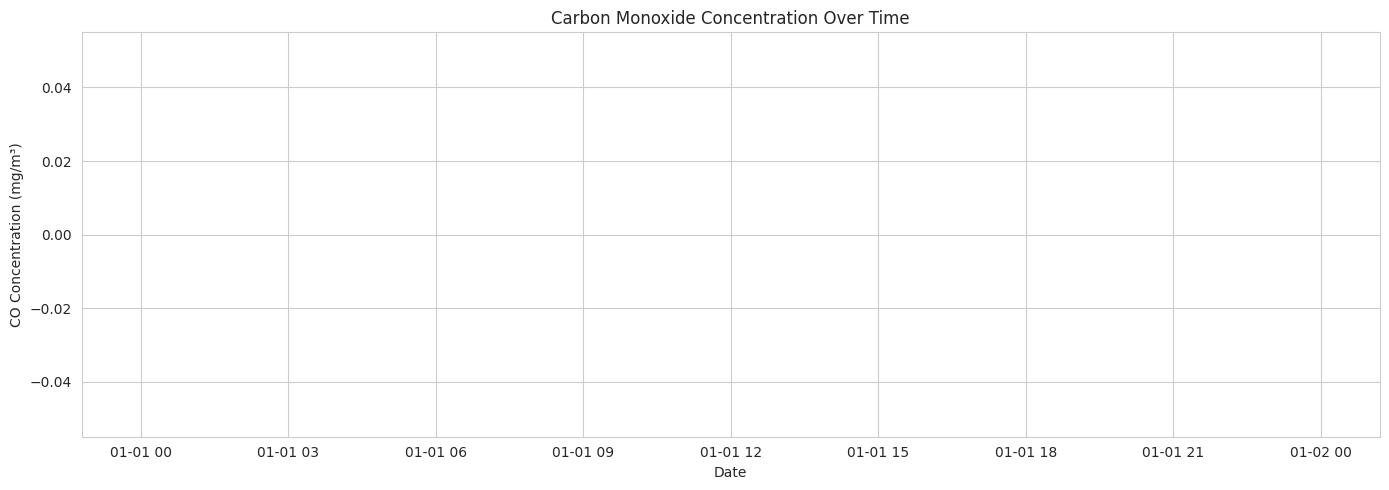

In [14]:
plt.figure(figsize=(14, 5))

plt.plot(
    df.index,
    df["CO(GT)"],
    color="red",
    linewidth=0.8
)

plt.title("Carbon Monoxide Concentration Over Time")
plt.xlabel("Date")
plt.ylabel("CO Concentration (mg/m³)")
plt.tight_layout()
plt.show()

12. DAILY AVERAGE CO

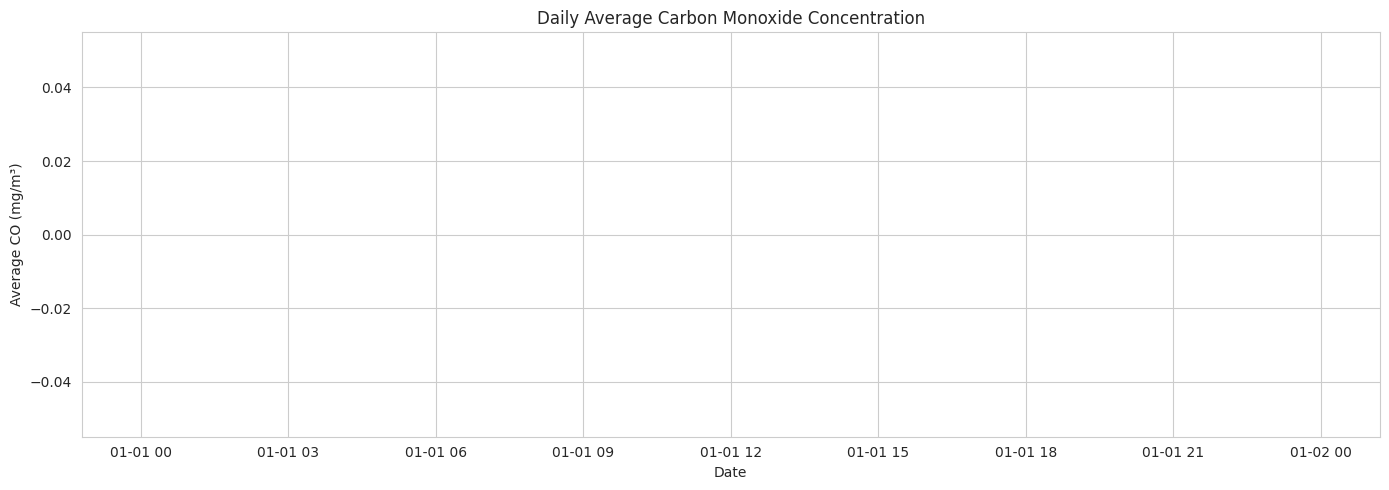

In [23]:
# Make absolutely sure the index is a valid DatetimeIndex
df.index = pd.to_datetime(df.index, errors="coerce")

# Remove any invalid timestamps
df = df[~df.index.isna()].copy()

# Sort chronologically
df = df.sort_index()

# Calculate daily average
daily_co = df["CO(GT)"].resample("D").mean()

plt.figure(figsize=(14, 5))

plt.plot(
    daily_co.index,
    daily_co.values,
    color="darkred"
)

plt.title("Daily Average Carbon Monoxide Concentration")
plt.xlabel("Date")
plt.ylabel("Average CO (mg/m³)")

plt.tight_layout()
plt.show()


13. HOURLY CO PATTERN

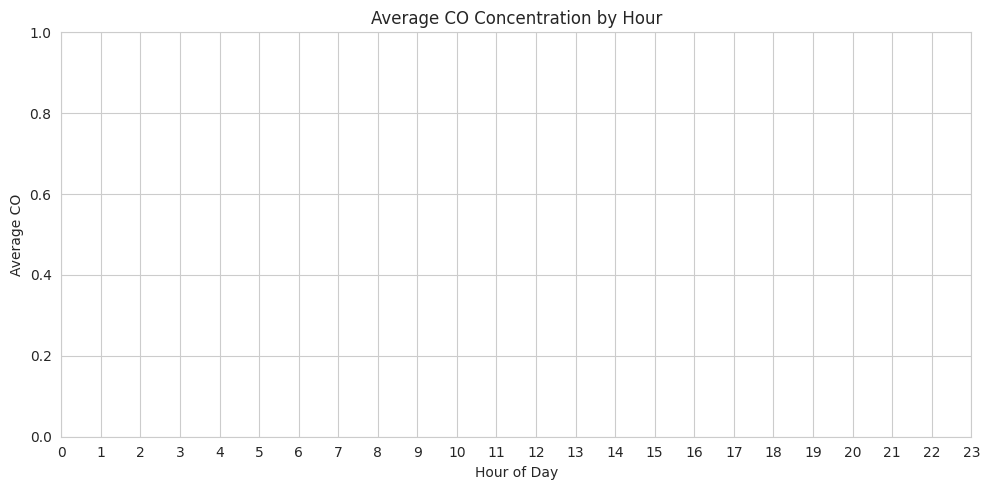

In [16]:
hourly_co = df.groupby("Hour")["CO(GT)"].mean()

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=hourly_co.index,
    y=hourly_co.values,
    marker="o",
    color="red"
)

plt.title("Average CO Concentration by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average CO")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

14. MONTHLY CO PATTERN

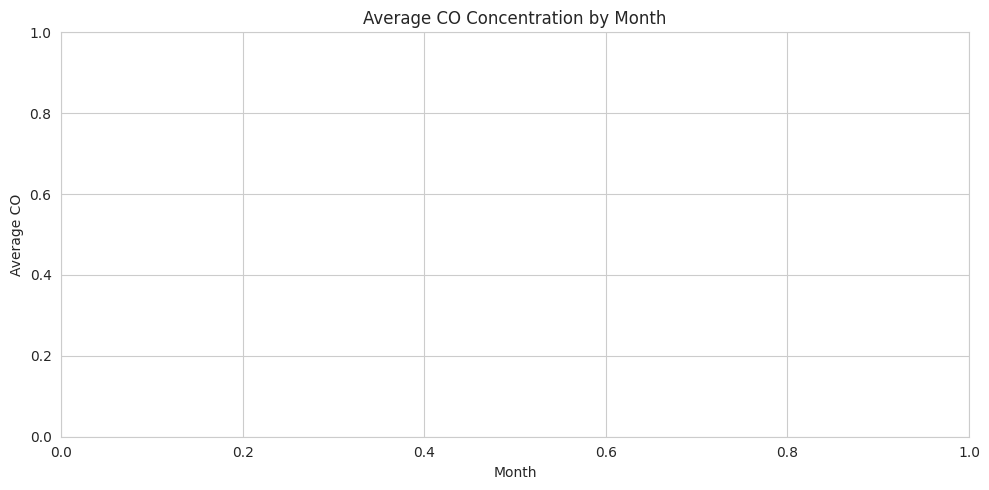

In [17]:
monthly_co = df.groupby("Month")["CO(GT)"].mean()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=monthly_co.index,
    y=monthly_co.values,
    color="steelblue"
)

plt.title("Average CO Concentration by Month")
plt.xlabel("Month")
plt.ylabel("Average CO")
plt.tight_layout()
plt.show()

15. TEMPERATURE VS CO

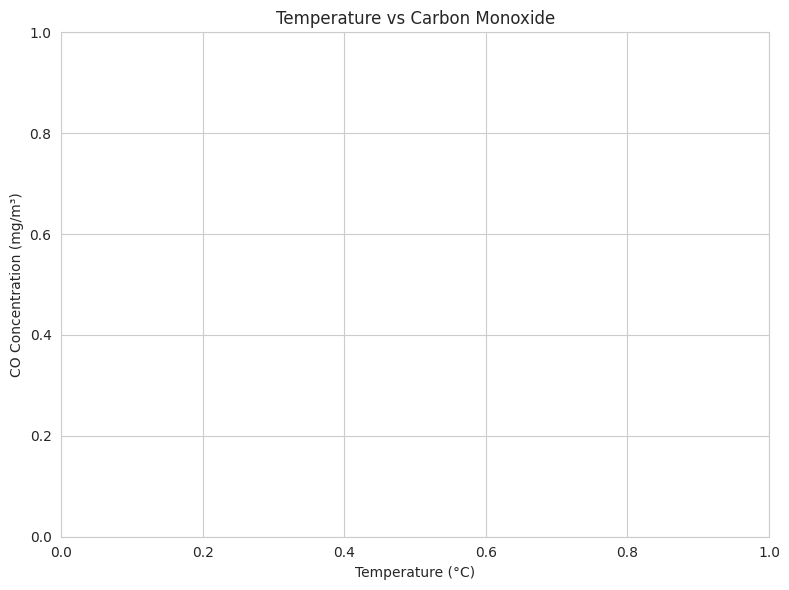

In [26]:
# Create a separate DataFrame for plotting
plot_df = df[["T", "CO(GT)"]].copy()

# Remove missing values
plot_df = plot_df.dropna()

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=plot_df["T"].to_numpy(),
    y=plot_df["CO(GT)"].to_numpy(),
    alpha=0.4,
    color="blue"
)

plt.title("Temperature vs Carbon Monoxide")
plt.xlabel("Temperature (°C)")
plt.ylabel("CO Concentration (mg/m³)")

plt.tight_layout()
plt.show()

16. HUMIDITY VS CO

Rows available for plotting: 0


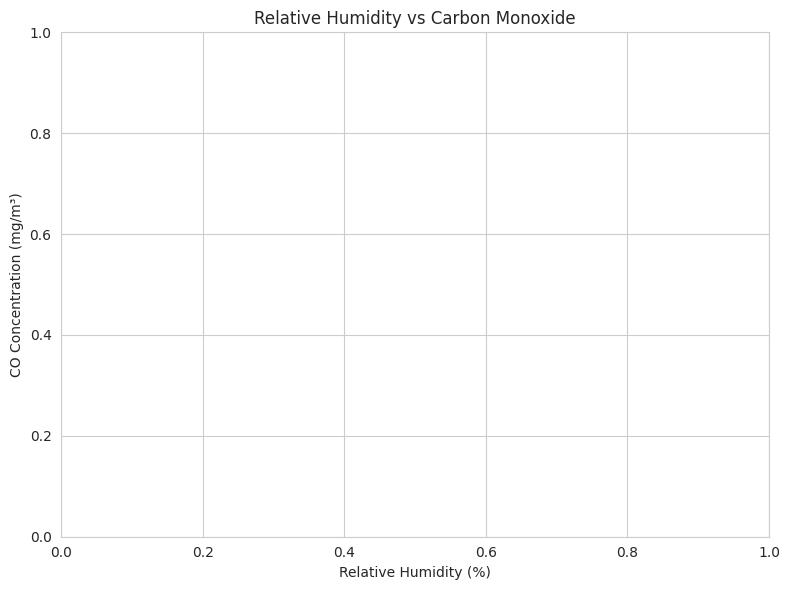

In [25]:

# Select only the required columns
plot_df = df[["RH", "CO(GT)"]].copy()

# Reset the index to remove any duplicate-index issues
plot_df = plot_df.reset_index(drop=True)

# Remove missing values
plot_df = plot_df.dropna()

print("Rows available for plotting:", len(plot_df))

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=plot_df["RH"].values,
    y=plot_df["CO(GT)"].values,
    alpha=0.4,
    color="green"
)

plt.title("Relative Humidity vs Carbon Monoxide")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("CO Concentration (mg/m³)")

plt.tight_layout()
plt.show()


17. CORRELATION ANALYSIS

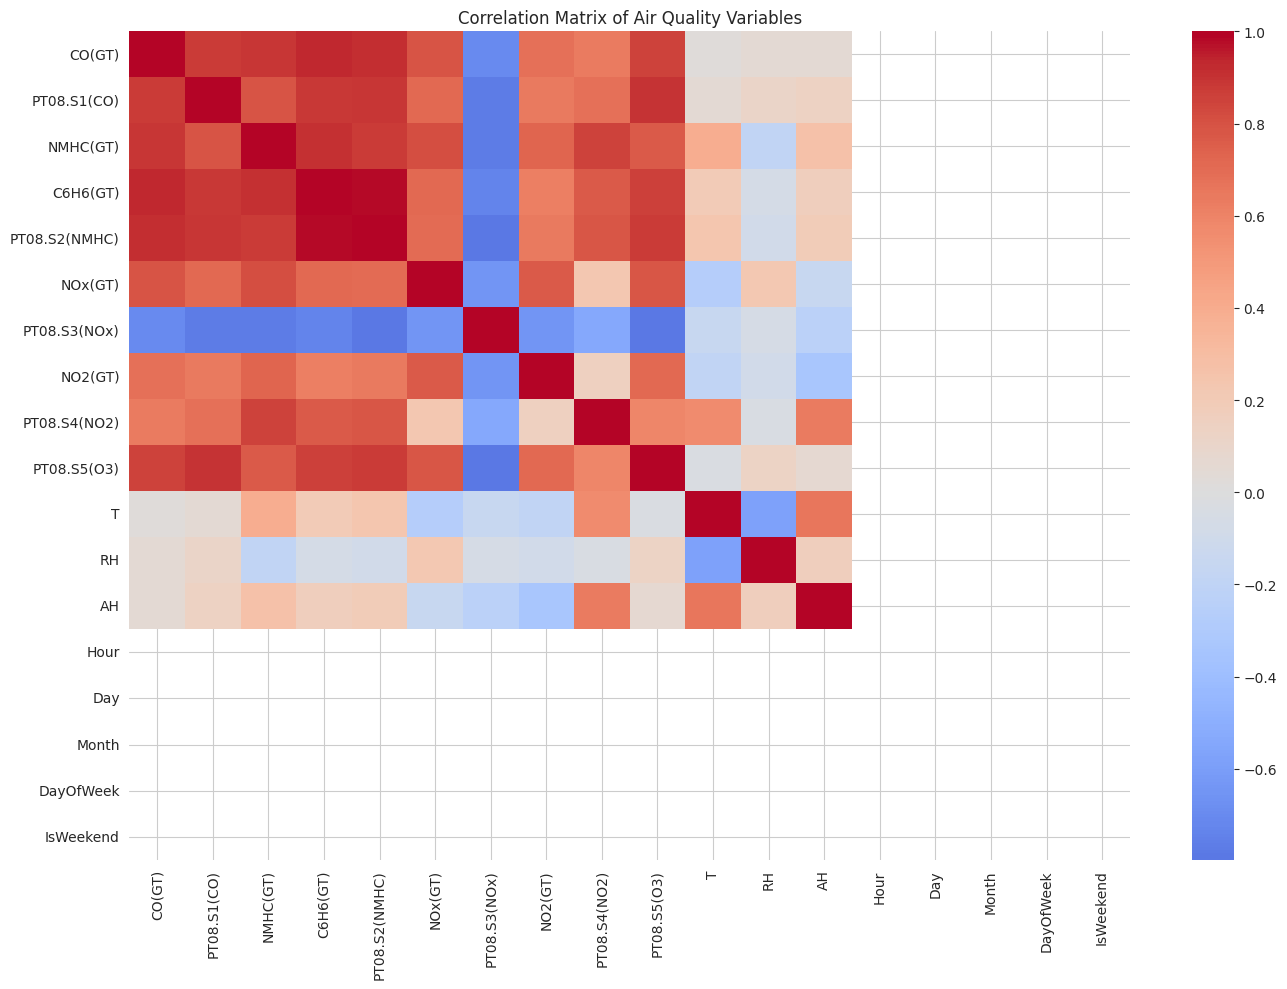

In [20]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Air Quality Variables")
plt.tight_layout()
plt.show()